In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])


In [3]:
df

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


In [48]:
df.shape

(1460, 3)

In [4]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [5]:
df.isnull().mean()

FireplaceQu    0.472603
GarageQual     0.055479
SalePrice      0.000000
dtype: float64

Text(0, 0.5, 'Number of houses')

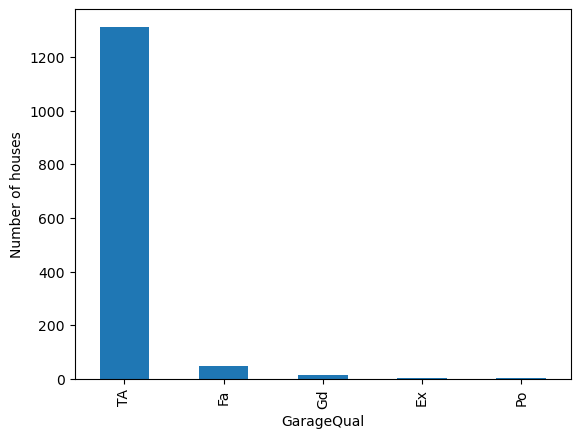

In [7]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of houses')

In [8]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

In [43]:
df['GarageQual'].isnull().sum()

0

In [45]:
df['GarageQual'].value_counts(dropna=False)

GarageQual
TA    1392
Fa      48
Gd      14
Ex       3
Po       3
Name: count, dtype: int64

ValueError: zero-size array to reduction operation fmax which has no identity

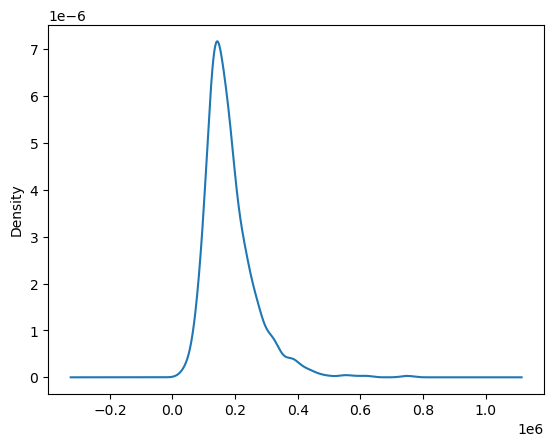

In [47]:
fig=plt.figure()
ax=fig.add_subplot(111)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax)
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines,labels=ax.get_legend_handles_labels()
labels=['Houses with TA', 'Houses with NA']
ax.legend(lines,labels,loc='best')

plt.title('GarageQual')
plt.show()


In [10]:
temp=df[df['GarageQual']=='TA']['SalePrice']


In [19]:
df['GarageQual']=df['GarageQual'].fillna('TA')

<Axes: xlabel='GarageQual'>

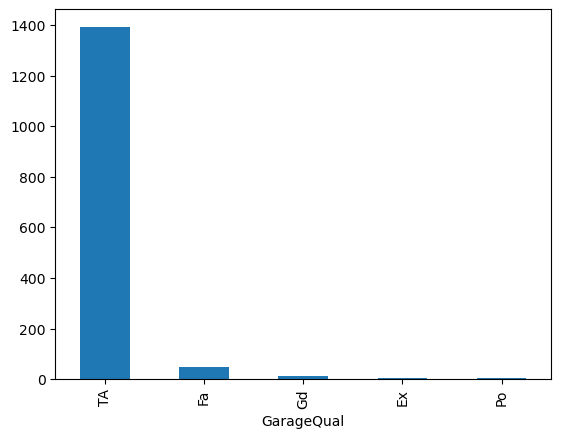

In [20]:
df['GarageQual'].value_counts().plot(kind='bar')


Text(0.5, 1.0, 'GarageQual')

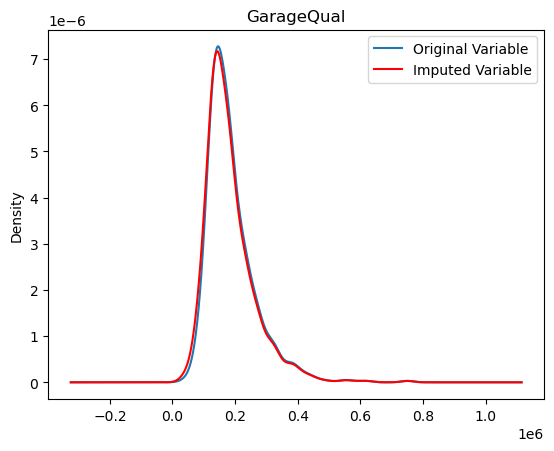

In [21]:
fig=plt.figure()
ax=fig.add_subplot(111)
temp.plot(kind='kde',ax=ax)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines,labels=ax.get_legend_handles_labels()
labels=['Original Variable','Imputed Variable']
ax.legend(lines,labels,loc='best')

plt.title('GarageQual')



<Axes: xlabel='FireplaceQu'>

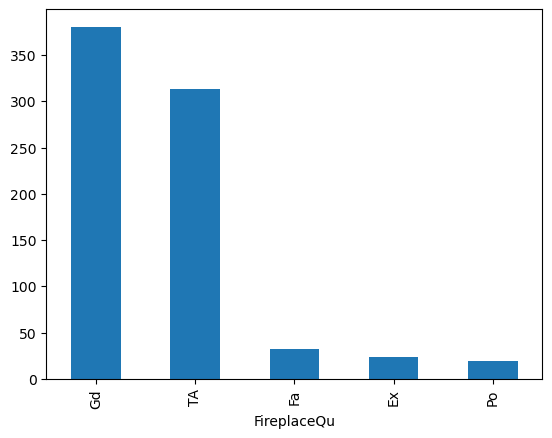

In [24]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [25]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

Text(0.5, 1.0, 'FireplaceQu')

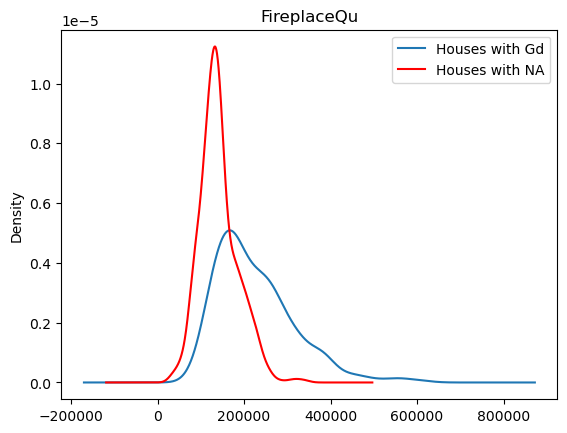

In [27]:
fig=plt.figure()
ax=fig.add_subplot(111)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color='red')
lines,labels=ax.get_legend_handles_labels()
labels=['Houses with Gd','Houses with NA']
ax.legend(lines,labels,loc='best')
plt.title('FireplaceQu')

In [28]:
temp=df[df['FireplaceQu']=='Gd']['SalePrice']


In [30]:
df['FireplaceQu'].fillna('Gd')

0       Gd
1       TA
2       TA
3       Gd
4       TA
        ..
1455    TA
1456    TA
1457    Gd
1458    Gd
1459    Gd
Name: FireplaceQu, Length: 1460, dtype: object

<Axes: xlabel='FireplaceQu'>

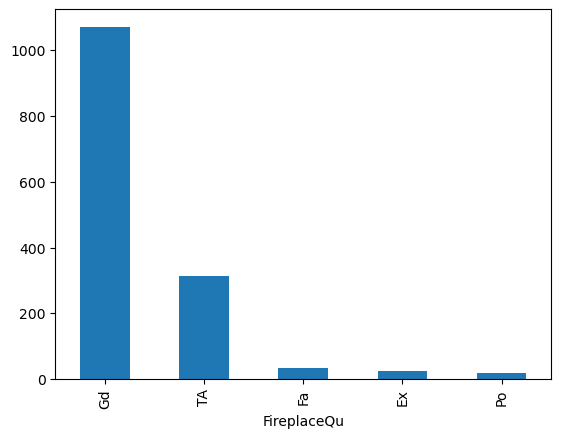

In [31]:
df['FireplaceQu'].value_counts().plot(kind='bar')


Text(0.5, 1.0, 'FireplaceQu')

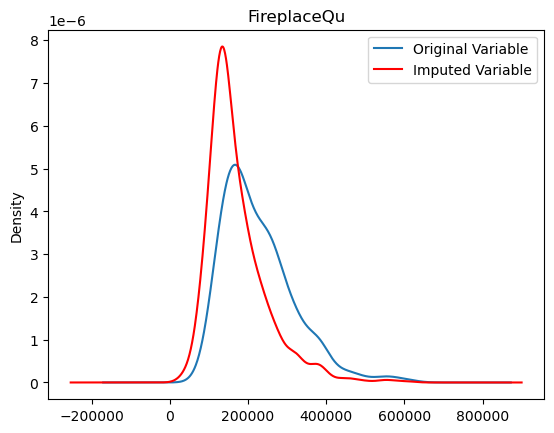

In [32]:
fig=plt.figure()
ax=fig.add_subplot(111)

temp.plot(kind='kde',ax=ax)
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax,color='red')
lines,labels=ax.get_legend_handles_labels()
labels=['Original Variable','Imputed Variable']
ax.legend(lines,labels,loc='best')
plt.title('FireplaceQu')


In [ ]:
#SKlearn :

In [33]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)


In [34]:
from sklearn.impute import SimpleImputer


In [35]:
imputer=SimpleImputer(strategy='most_frequent')


In [37]:
X_train=imputer.fit_transform(X_train)
X_test=imputer.transform(X_test)


In [38]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)